# Fase 3 — Estacionariedade

**Companion: Nielsen, cap. 3 e 6.** ARIMA pressupõe série **estacionária** (média e variância estáveis no tempo). Verificamos isso de duas formas: visualmente (estatísticas móveis) e com testes formais de hipótese.

| Teste | H0 (hipótese nula) | p < 0.05 significa |
|---|---|---|
| **ADF** | tem raiz unitária (NÃO estacionária) | rejeita H0 ⇒ **estacionária** |
| **KPSS** | É estacionária | rejeita H0 ⇒ **não estacionária** |

Os dois têm hipóteses nulas *opostas*; combiná-los evita conclusões precipitadas.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from series_eco.data import loaders
from series_eco.eda import stationarity, plots

ipca = loaders.load_panel("2000-01-01")["ipca"]
ipca.describe()

count    316.000000
mean       0.497184
std        0.392404
min       -0.680000
25%        0.257500
50%        0.450000
75%        0.670000
max        3.020000
Name: ipca, dtype: float64

## 1. Diagnóstico visual

Antes dos testes: se a média móvel é aproximadamente plana e o desvio móvel é estável, a série *parece* estacionária. Compare o IPCA em nível com sua primeira diferença.

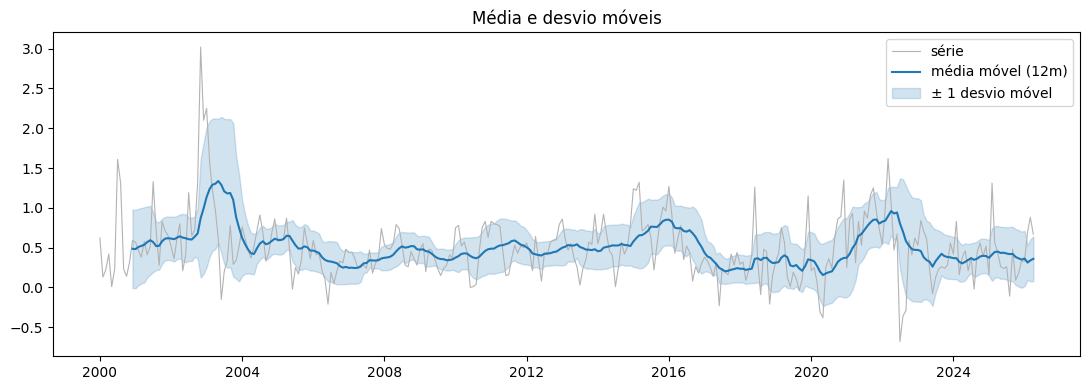

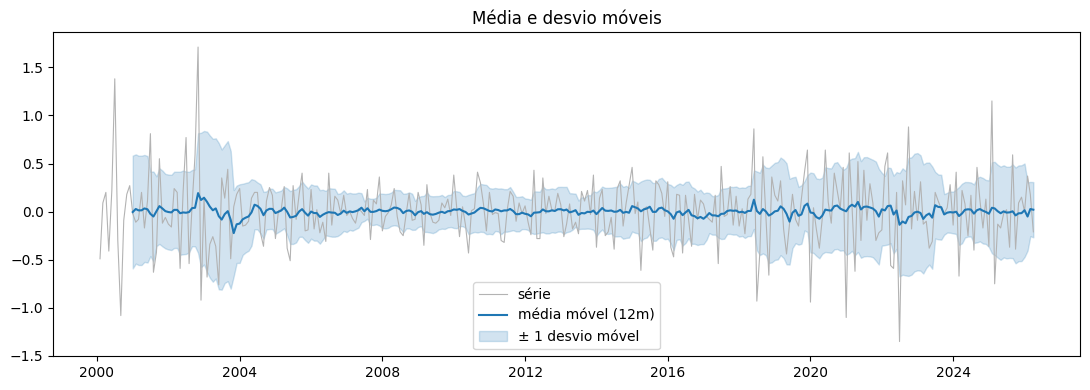

In [2]:
plots.plot_rolling_stats(ipca, window=12)
plt.show()
plots.plot_rolling_stats(ipca.diff().dropna(), window=12)
plt.show()

## 2. Testes formais no IPCA em nível

Rodamos ADF + KPSS e olhamos o veredito combinado.

In [3]:
rel = stationarity.stationarity_report(ipca)
print(f"ADF : stat={rel.adf.statistic:.3f}  p={rel.adf.pvalue:.4f}  estacionária={rel.adf.is_stationary}")
print(f"KPSS: stat={rel.kpss.statistic:.3f}  p={rel.kpss.pvalue:.4f}  estacionária={rel.kpss.is_stationary}")
print(f"\nVeredito: {rel.verdict}")

ADF : stat=-8.794  p=0.0000  estacionária=True
KPSS: stat=0.253  p=0.1000  estacionária=True

Veredito: estacionária


## 3. Quantas diferenças bastam?

`ndiffs` aplica diferenças sucessivas até o ADF acusar estacionariedade — esse número é a ordem `d` do ARIMA(p, **d**, q).

In [4]:
d = stationarity.ndiffs(ipca)
print(f"d sugerido = {d}")

rel_diff = stationarity.stationarity_report(ipca.diff().dropna())
print(f"\nApós 1 diferença -> veredito: {rel_diff.verdict}")
print(f"  ADF p={rel_diff.adf.pvalue:.4f} | KPSS p={rel_diff.kpss.pvalue:.4f}")

d sugerido = 0

Após 1 diferença -> veredito: estacionária
  ADF p=0.0000 | KPSS p=0.1000


---
**Conclusão econômica + estatística:** como o IPCA da série 433 já é uma *variação mensal* (uma taxa), faz sentido econômico que não tenha tendência explosiva — e de fato os testes costumam indicar `d = 0`. A sazonalidade vista na Fase 2 permanece, apontando para termos **sazonais** no SARIMA (Fase 4), não para diferenciação regular.